# SST in Mar 2023 in HRDPS 1km and HRDPS 2.5km Driven Results

## SST (Old and Wrong)

Date        : 20230301
Time index  : 0
HRDPS 1 time   : 2023-03-01T12:00:00.000000000
HRDPS time  : 2023-03-01T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230315
Time index  : 14
HRDPS 1 time   : 2023-03-15T12:00:00.000000000
HRDPS time  : 2023-03-15T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230328
Time index  : 27
HRDPS 1 time   : 2023-03-28T12:00:00.000000000
HRDPS time  : 2023-03-28T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)

Color ranges:
SST  : -32.074 to 10.027 °C
Diff : -40.975 to 40.975 °C


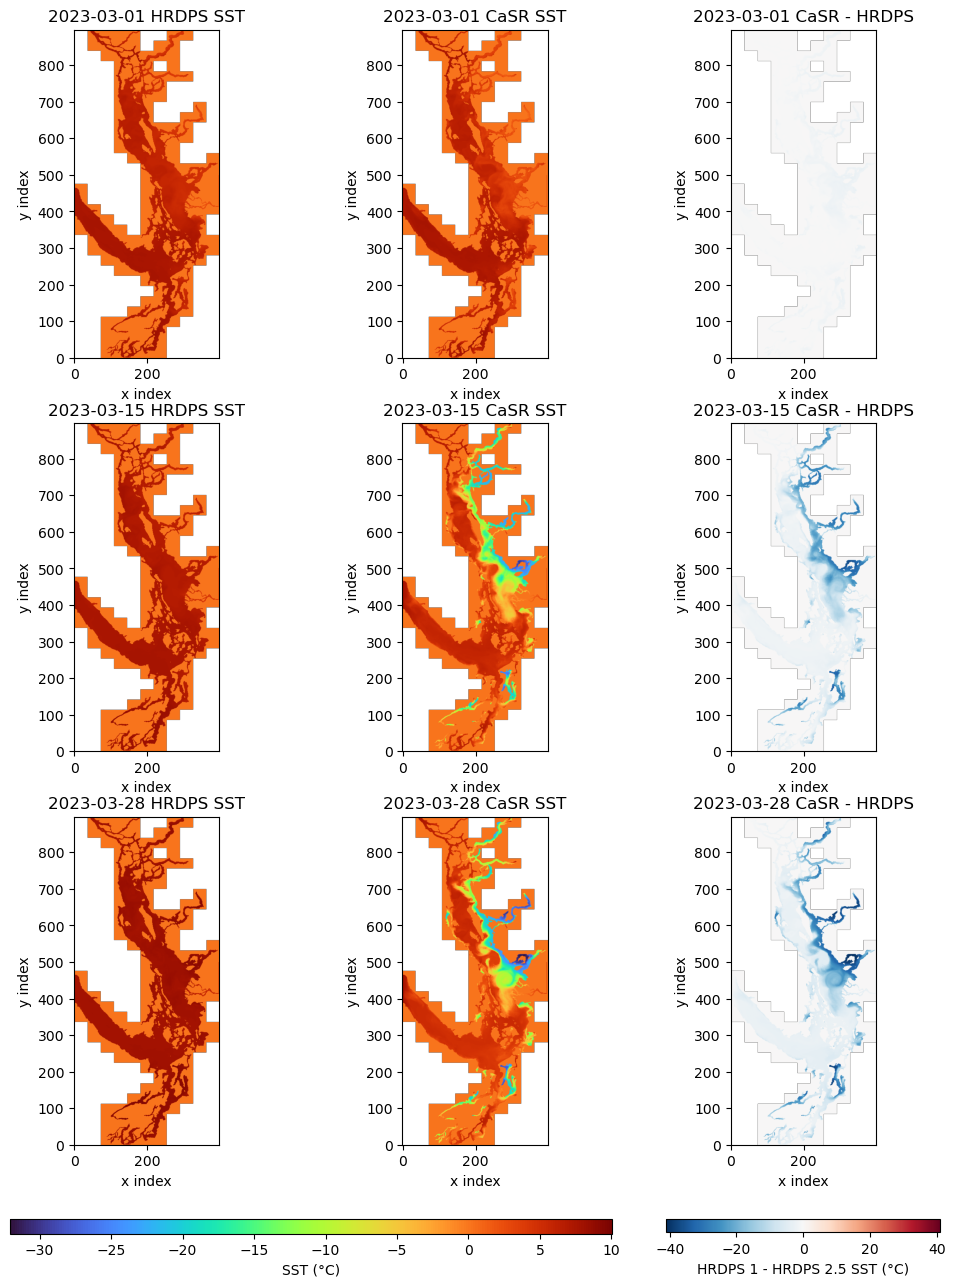

In [1]:
# HRDPS 1km vs HRDPS 2.5 km driven SST

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# 1d grid_T files
# ============================================================
path_grid_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/'
    'SalishSea_1d_20230301_20230328_grid_T.nc'
)

path_grid_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_grid_casr)
hrdps_ds = xr.open_dataset(path_grid_hrdps)


# ============================================================
# Choose 3 days
#
# For 1d monthly files:
# March 1  -> time index 0
# March 15 -> time index 14
# March 31 -> time index 30
# ============================================================
days = [
    "20230301",
    "20230315",
    "20230328",
]

day_numbers = [1, 15, 28]

depth_idx = 0


# ============================================================
# Read SST data
# ============================================================
all_data = []

for date_str, day_num in zip(days, day_numbers):

    # ========================================================
    # Time index for 1d monthly file
    # ========================================================
    tidx = day_num - 1


    # ========================================================
    # SST
    # ========================================================
    casr_sst = casr_ds['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values

    hrdps_sst = hrdps_ds['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values


    # ========================================================
    # Difference
    # positive = CaSR warmer than HRDPS
    # ========================================================
    diff = casr_sst - hrdps_sst


    # ========================================================
    # Time information
    # ========================================================
    casr_time = casr_ds.time_counter.isel(
        time_counter=tidx
    ).values

    hrdps_time = hrdps_ds.time_counter.isel(
        time_counter=tidx
    ).values


    print("=" * 60)
    print(f"Date        : {date_str}")
    print(f"Time index  : {tidx}")
    print(f"HRDPS 1 time   : {casr_time}")
    print(f"HRDPS time  : {hrdps_time}")
    print(f"HRDPS 1 shape  : {casr_sst.shape}")
    print(f"HRDPS shape : {hrdps_sst.shape}")


    # ========================================================
    # Save for plotting
    # ========================================================
    all_data.append({
        'date': date_str,
        'hrdps': hrdps_sst,
        'casr': casr_sst,
        'diff': diff,
    })


# ============================================================
# Unified SST color range
# across all 3 days and both datasets
# ============================================================
all_sst_values = []

for data in all_data:

    all_sst_values.append(
        data['hrdps'][np.isfinite(data['hrdps'])]
    )

    all_sst_values.append(
        data['casr'][np.isfinite(data['casr'])]
    )

all_sst_values = np.concatenate(all_sst_values)

sst_vmin = np.nanmin(all_sst_values)
sst_vmax = np.nanmax(all_sst_values)


# ============================================================
# Unified difference color range
# symmetric around zero
# ============================================================
all_diff_values = []

for data in all_data:

    all_diff_values.append(
        data['diff'][np.isfinite(data['diff'])]
    )

all_diff_values = np.concatenate(all_diff_values)

diff_max = np.nanmax(np.abs(all_diff_values))

diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)


print("\nColor ranges:")
print(f"SST  : {sst_vmin:.3f} to {sst_vmax:.3f} °C")
print(f"Diff : {-diff_max:.3f} to {diff_max:.3f} °C")


# ============================================================
# Plot: 3 rows × 3 columns
#
# column 1: HRDPS SST
# column 2: CaSR SST
# column 3: CaSR - HRDPS
# ============================================================
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 16)
)


for row, data in enumerate(all_data):

    date_str = data['date']

    hrdps_sst = data['hrdps']
    casr_sst = data['casr']
    diff = data['diff']

    date_label = (
        f'{date_str[:4]}-'
        f'{date_str[4:6]}-'
        f'{date_str[6:]}'
    )


    # ========================================================
    # HRDPS SST
    # ========================================================
    im_sst = axes[row, 0].imshow(
        hrdps_sst,
        origin='lower',
        cmap='turbo',
        vmin=sst_vmin,
        vmax=sst_vmax,
        aspect='equal'
    )

    axes[row, 0].set_title(
        f'{date_label} HRDPS SST'
    )

    axes[row, 0].set_xlabel('x index')
    axes[row, 0].set_ylabel('y index')


    # ========================================================
    # CaSR SST
    # ========================================================
    axes[row, 1].imshow(
        casr_sst,
        origin='lower',
        cmap='turbo',
        vmin=sst_vmin,
        vmax=sst_vmax,
        aspect='equal'
    )

    axes[row, 1].set_title(
        f'{date_label} CaSR SST'
    )

    axes[row, 1].set_xlabel('x index')
    axes[row, 1].set_ylabel('y index')


    # ========================================================
    # Difference
    # ========================================================
    im_diff = axes[row, 2].imshow(
        diff,
        origin='lower',
        cmap='RdBu_r',
        norm=diff_norm,
        aspect='equal'
    )

    axes[row, 2].set_title(
        f'{date_label} CaSR - HRDPS'
    )

    axes[row, 2].set_xlabel('x index')
    axes[row, 2].set_ylabel('y index')


# # ============================================================
# # Adjust space
# # leave space at bottom for horizontal colorbars
# # ============================================================
# plt.subplots_adjust(
#     left=0.07,
#     right=0.97,
#     top=0.95,
#     bottom=0.12,
#     wspace=0.15,
#     hspace=0.18
# )


# ============================================================
# SST colorbar
# shared by first two columns
# ============================================================
cbar_sst = fig.colorbar(
    im_sst,
    ax=axes[:, 0:2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=40
)

cbar_sst.set_label('SST (°C)')


# ============================================================
# Difference colorbar
# shared by third column
# ============================================================
cbar_diff = fig.colorbar(
    im_diff,
    ax=axes[:, 2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=20
)

cbar_diff.set_label('HRDPS 1 - HRDPS 2.5 SST (°C)')


plt.show()


# ============================================================
# Close files
# ============================================================
casr_ds.close()
hrdps_ds.close()

Apparently something is seriously wrong.

## Forcing Field Examination

In [2]:
# find nearest grid point

import numpy as np

import xarray as xr

path_forcing_casr_01='/ocean/jqiu/forcings/HRDPS_1km/HRDPS_1km_y2023m03d01.nc'
path_forcing_hrdps_01='/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2023m03d01.nc'

ds_forcing_casr_01=xr.open_dataset(path_forcing_casr_01)
ds_forcing_hrdps_01=xr.open_dataset(path_forcing_hrdps_01)

locations = {
    "Pam Rocks": (49.49, -123.3),
    "Sand Heads": (49.11, -123.3),
}

datasets = {
    "CaSR": ds_forcing_casr_01,
    "HRDPS": ds_forcing_hrdps_01,
}

for ds_name, ds in datasets.items():

    lat = ds.nav_lat.values
    lon = ds.nav_lon.values

    print(f"\n===== {ds_name} =====")

    for name, (target_lat, target_lon) in locations.items():

        # convert longitude from [-180, 180] to [0, 360]
        target_lon = target_lon + 360

        # simple squared distance in lat/lon space
        dist2 = (lat - target_lat)**2 + (lon - target_lon)**2

        # find nearest grid point
        j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)

        print(name)
        print("  y index =", j)
        print("  x index =", i)
        print("  grid lat =", lat[j, i])
        print("  grid lon =", lon[j, i])
        print()


===== CaSR =====
Pam Rocks
  y index = 261
  x index = 372
  grid lat = 49.494852
  grid lon = 236.69994400000002

Sand Heads
  y index = 222
  x index = 354
  grid lat = 49.108804
  grid lon = 236.697552


===== HRDPS =====
Pam Rocks
  y index = 135
  x index = 110
  grid lat = 49.481496
  grid lon = 236.694728

Sand Heads
  y index = 119
  x index = 108
  grid lat = 49.118712
  grid lon = 236.693408



In [4]:
# Extract forcing data at 2 locations

import xarray as xr
import pandas as pd
from pathlib import Path
import glob


# ============================================================
# 1. Paths
# ============================================================

casr_dir = Path("/ocean/jqiu/forcings/HRDPS_1km")
hrdps_dir = Path(
    "/results/forcing/atmospheric/continental2.5/nemo_forcing"
)

casr_files = sorted(
    glob.glob(str(casr_dir / "HRDPS_1km_y2023m03d*.nc"))
)

hrdps_files = sorted(
    glob.glob(str(hrdps_dir / "hrdps_y2023m03d*.nc"))
)

print(f"CaSR files  : {len(casr_files)}")
# print(f"HRDPS files : {len(hrdps_files)}")


# ============================================================
# 2. Only read these variables
# ============================================================

forcing_vars = [
    "solar",
    "precip",
    "therm_rad",
    "tair",
    "qair",
    "u_wind",
    "atmpres",
    "v_wind",
]


# ============================================================
# 3. Grid indices
# ============================================================

stations = {
    "PamRocks": {
        "CaSR": {
            "y": 261,
            "x": 372,
        },
        "HRDPS": {
            "y": 135,
            "x": 110,
        },
    },

    "SandHeads": {
        "CaSR": {
            "y": 222,
            "x": 354,
        },
        "HRDPS": {
            "y": 119,
            "x": 108,
        },
    },
}


# ============================================================
# 4. Open March 2023 datasets
# ============================================================

ds_casr = xr.open_mfdataset(
    casr_files,
    combine="by_coords",
    parallel=True,
    chunks={"time_counter": 24},
)[forcing_vars]

# ds_hrdps = xr.open_mfdataset(
#     hrdps_files,
#     combine="by_coords",
#     parallel=True,
#     chunks={"time_counter": 24},
# )[forcing_vars]


# print("\nCaSR:")
# print(ds_casr)

# print("\nHRDPS:")
# print(ds_hrdps)


# ============================================================
# 5. Function for extracting one grid point
# ============================================================

def save_grid_point_csv(
    ds,
    forcing_name,
    station_name,
    y_idx,
    x_idx,
    output_file,
):

    # --------------------------------------------------------
    # Extract specified grid point
    # --------------------------------------------------------

    point = ds[forcing_vars].isel(
        y=y_idx,
        x=x_idx,
    )

    # --------------------------------------------------------
    # Grid coordinates
    # --------------------------------------------------------

    grid_lat = float(
        ds["nav_lat"].isel(
            y=y_idx,
            x=x_idx,
        ).values
    )

    grid_lon = float(
        ds["nav_lon"].isel(
            y=y_idx,
            x=x_idx,
        ).values
    )

    # convert 0--360 longitude to -180--180
    grid_lon_180 = (
        grid_lon - 360
        if grid_lon > 180
        else grid_lon
    )

    # print(
    #     f"\n{forcing_name} - {station_name}"
    # )

    # print(
    #     f"y = {y_idx}, x = {x_idx}"
    # )

    # print(
    #     f"lat = {grid_lat:.6f}, "
    #     f"lon = {grid_lon:.6f}, "
    #     f"lon180 = {grid_lon_180:.6f}"
    # )

    # --------------------------------------------------------
    # Convert to DataFrame
    # --------------------------------------------------------

    df = point.to_dataframe().reset_index()

    # Remove x/y if xarray puts them into dataframe
    for col in ["x", "y"]:
        if col in df.columns:
            df = df.drop(columns=col)

    # --------------------------------------------------------
    # Add grid information
    # --------------------------------------------------------

    df["grid_y"] = y_idx
    df["grid_x"] = x_idx
    df["grid_lat"] = grid_lat
    df["grid_lon"] = grid_lon
    df["grid_lon_180"] = grid_lon_180

    # --------------------------------------------------------
    # Desired column order
    # --------------------------------------------------------

    columns = [
        "time_counter",
        "grid_y",
        "grid_x",
        "grid_lat",
        "grid_lon",
        "grid_lon_180",
        "solar",
        "precip",
        "therm_rad",
        "tair",
        "qair",
        "u_wind",
        "atmpres",
        "v_wind",
    ]

    df = df[columns]

    # --------------------------------------------------------
    # Sort chronologically
    # --------------------------------------------------------

    df = df.sort_values(
        "time_counter"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Write CSV
    # --------------------------------------------------------

    df.to_csv(
        output_file,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S",
    )

    print(
        f"Saved: {output_file}"
    )

    print(
        f"Number of records: {len(df)}"
    )

    return df


# ============================================================
# 6. Save four CSV files
# ============================================================

df_casr_pam = save_grid_point_csv(
    ds=ds_casr,
    forcing_name="HRDPS 1",
    station_name="Pam Rocks",
    y_idx=stations["PamRocks"]["CaSR"]["y"],
    x_idx=stations["PamRocks"]["CaSR"]["x"],
    output_file="HRDPS_1km_PamRocks_202303.csv",
)


df_casr_sand = save_grid_point_csv(
    ds=ds_casr,
    forcing_name="HRDPS 1km",
    station_name="Sand Heads",
    y_idx=stations["SandHeads"]["CaSR"]["y"],
    x_idx=stations["SandHeads"]["CaSR"]["x"],
    output_file="HRDPS_1km_SandHeads_202303.csv",
)


# df_hrdps_pam = save_grid_point_csv(
#     ds=ds_hrdps,
#     forcing_name="HRDPS",
#     station_name="Pam Rocks",
#     y_idx=stations["PamRocks"]["HRDPS"]["y"],
#     x_idx=stations["PamRocks"]["HRDPS"]["x"],
#     output_file="HRDPS_PamRocks_202303.csv",
# )


# df_hrdps_sand = save_grid_point_csv(
#     ds=ds_hrdps,
#     forcing_name="HRDPS",
#     station_name="Sand Heads",
#     y_idx=stations["SandHeads"]["HRDPS"]["y"],
#     x_idx=stations["SandHeads"]["HRDPS"]["x"],
#     output_file="HRDPS_SandHeads_202303.csv",
# )


# ============================================================
# 7. Close datasets
# ============================================================

ds_casr.close()
# ds_hrdps.close()

print("\nAll done.")

CaSR files  : 28
Saved: HRDPS_1km_PamRocks_202303.csv
Number of records: 672
Saved: HRDPS_1km_SandHeads_202303.csv
Number of records: 672

All done.


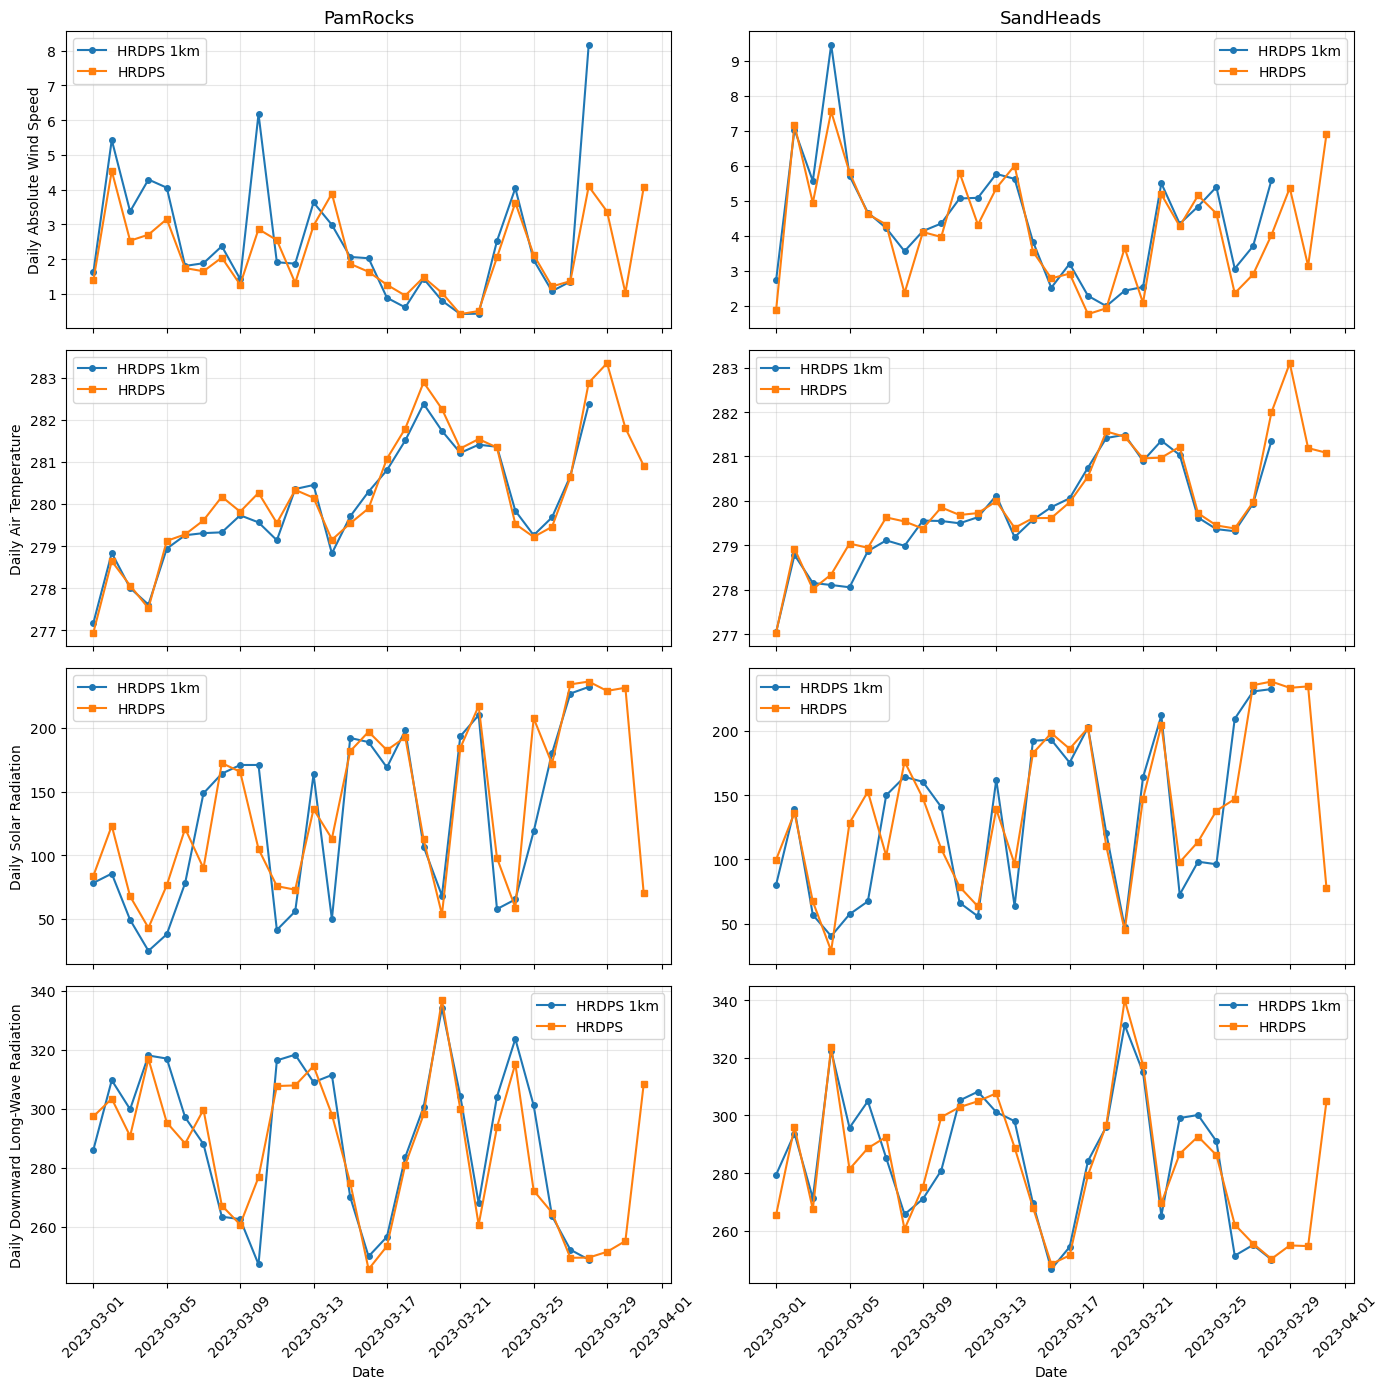

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# File paths
# ============================================================
path_casr_pamrocks = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Analysis_results_comparison/00Mar2023_flux/'
    'HRDPS_1km_PamRocks_202303.csv'
)

path_hrdps_pamrocks = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Analysis_results_comparison/00Mar2023_flux/'
    'HRDPS_PamRocks_202303.csv'
)

path_casr_sandheads = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Analysis_results_comparison/00Mar2023_flux/'
    'HRDPS_1km_SandHeads_202303.csv'
)

path_hrdps_sandheads = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Analysis_results_comparison/00Mar2023_flux/'
    'HRDPS_SandHeads_202303.csv'
)


# ============================================================
# Read CSV and calculate daily means
# ============================================================
def read_daily_mean(path):
    df = pd.read_csv(path)

    # Convert time to datetime
    df['time_counter'] = pd.to_datetime(df['time_counter'])

    # Absolute wind speed
    df['wind_speed'] = np.sqrt(
        df['u_wind']**2 + df['v_wind']**2
    )

    # Set time as index, then calculate daily mean
    df = df.set_index('time_counter')

    daily = df[
        ['wind_speed', 'tair', 'solar', 'therm_rad']
    ].resample('1D').mean()

    return daily


# ============================================================
# Load all four datasets
# ============================================================
casr_pam = read_daily_mean(path_casr_pamrocks)
hrdps_pam = read_daily_mean(path_hrdps_pamrocks)

casr_sand = read_daily_mean(path_casr_sandheads)
hrdps_sand = read_daily_mean(path_hrdps_sandheads)


# ============================================================
# Plot: 4 variables × 2 locations
# ============================================================
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 14),
    sharex=True
)

variables = [
    ('wind_speed', 'Daily Absolute Wind Speed'),
    ('tair', 'Daily Air Temperature'),
    ('solar', 'Daily Solar Radiation'),
    ('therm_rad', 'Daily Downward Long-Wave Radiation')
]

locations = [
    ('PamRocks', casr_pam, hrdps_pam),
    ('SandHeads', casr_sand, hrdps_sand)
]

for row, (var, ylabel) in enumerate(variables):

    for col, (location, casr, hrdps) in enumerate(locations):

        ax = axes[row, col]

        # CaSR
        ax.plot(
            casr.index,
            casr[var],
            marker='o',
            markersize=4,
            linewidth=1.5,
            label='HRDPS 1km'
        )

        # HRDPS
        ax.plot(
            hrdps.index,
            hrdps[var],
            marker='s',
            markersize=4,
            linewidth=1.5,
            label='HRDPS'
        )

        ax.grid(True, alpha=0.3)

        # Location titles only on the top row
        if row == 0:
            ax.set_title(location, fontsize=13)

        # Variable label on left side
        if col == 0:
            ax.set_ylabel(ylabel)

        # Legend
        ax.legend()

        # Rotate dates
        ax.tick_params(axis='x', rotation=45)


# X label on bottom row
axes[-1, 0].set_xlabel('Date')
axes[-1, 1].set_xlabel('Date')


plt.tight_layout()



plt.show()

## Flux Inspection

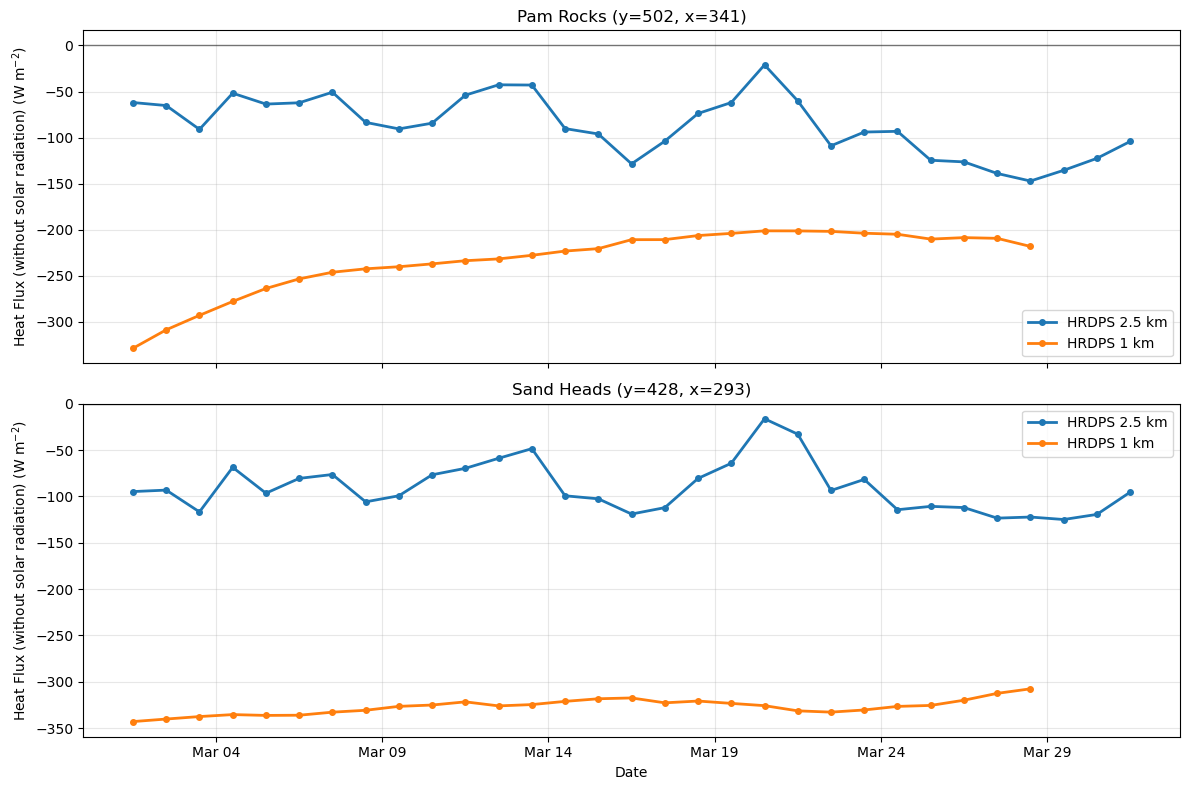

In [10]:
# Heat Flux (without solar radiation)
# Surface Heat Flux Time Series

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# Paths: 1d sbfx_T
# ============================================================
path_CaSR_flux = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/'
    'SalishSea_1d_20230301_20230328_sbfx_T.nc'
)

path_HRDPS25_flux = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
flux_casr = xr.open_dataset(path_CaSR_flux)
flux_hrdps = xr.open_dataset(path_HRDPS25_flux)


# ============================================================
# Stations
# ============================================================
stations = {
    'Pam Rocks': {
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    'Sand Heads': {
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
}


# ============================================================
# Time
# ============================================================
casr_time = flux_casr['time_counter'].values
hrdps_time = flux_hrdps['time_counter'].values


# ============================================================
# Plot
#
# one panel for each station
# ============================================================
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True
)


for ax, (station_name, station) in zip(
    axes,
    stations.items()
):

    y_idx = station['y']
    x_idx = station['x']


    # ========================================================
    # CaSR total surface heat flux
    #
    # Keep the full time_counter dimension
    # ========================================================
    casr_heat = (
        flux_casr['longwave_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_casr['sensible_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_casr['latent_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_casr['emp_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
    ).values


    # ========================================================
    # HRDPS 2.5 km total surface heat flux
    #
    # Keep the full time_counter dimension
    # ========================================================
    hrdps_heat = (
        flux_hrdps['longwave_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_hrdps['sensible_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_hrdps['latent_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_hrdps['emp_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
    ).values


    # ========================================================
    # Plot
    # ========================================================
    ax.plot(
        hrdps_time,
        hrdps_heat,
        marker='o',
        markersize=4,
        linewidth=2,
        label='HRDPS 2.5 km'
    )

    ax.plot(
        casr_time,
        casr_heat,
        marker='o',
        markersize=4,
        linewidth=2,
        label='HRDPS 1 km'
    )


    # ========================================================
    # Zero line
    # ========================================================
    ax.axhline(
        0,
        color='k',
        linewidth=1,
        alpha=0.5
    )


    # ========================================================
    # Station title
    # ========================================================
    ax.set_title(
        f"{station_name} "
        f"(y={y_idx}, x={x_idx})"
    )


    # ========================================================
    # Labels
    # ========================================================
    ax.set_ylabel('Heat Flux (without solar radiation) (W m$^{-2}$)')


    # ========================================================
    # Grid
    # ========================================================
    ax.grid(
        True,
        alpha=0.3
    )


    # ========================================================
    # Legend
    # ========================================================
    ax.legend()


# ============================================================
# Date axis
# ============================================================
axes[-1].set_xlabel('Date')

axes[-1].xaxis.set_major_locator(
    mdates.DayLocator(interval=5)
)

axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter('%b %d')
)


plt.tight_layout()

plt.show()


# ============================================================
# Close datasets
# ============================================================
flux_casr.close()
flux_hrdps.close()

## SST (New and probably good)

Date        : 20230301
Time index  : 0
HRDPS 1 time   : 2023-03-01T12:00:00.000000000
HRDPS time  : 2023-03-01T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230315
Time index  : 14
HRDPS 1 time   : 2023-03-15T12:00:00.000000000
HRDPS time  : 2023-03-15T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230328
Time index  : 27
HRDPS 1 time   : 2023-03-28T12:00:00.000000000
HRDPS time  : 2023-03-28T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)

Color ranges:
SST  : 0.000 to 10.416 °C
Diff : -2.018 to 2.018 °C


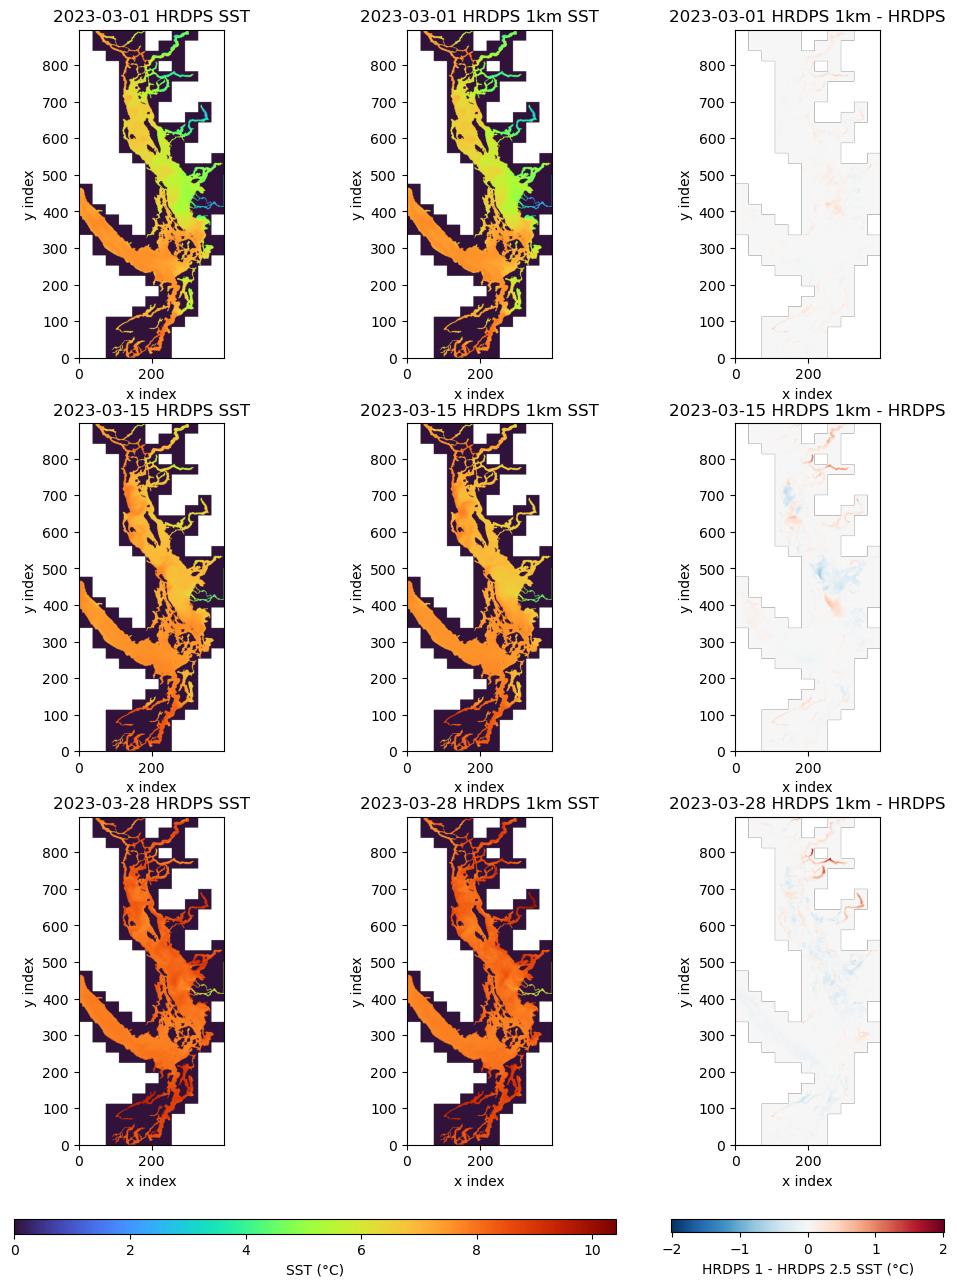

In [2]:
# HRDPS 1km vs HRDPS 2.5 km driven SST

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# 1d grid_T files
# ============================================================
path_grid_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/'
    'SalishSea_1d_20230301_20230328_grid_T.nc'
)

path_grid_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_grid_casr)
hrdps_ds = xr.open_dataset(path_grid_hrdps)


# ============================================================
# Choose 3 days
#
# For 1d monthly files:
# March 1  -> time index 0
# March 15 -> time index 14
# March 31 -> time index 30
# ============================================================
days = [
    "20230301",
    "20230315",
    "20230328",
]

day_numbers = [1, 15, 28]

depth_idx = 0


# ============================================================
# Read SST data
# ============================================================
all_data = []

for date_str, day_num in zip(days, day_numbers):

    # ========================================================
    # Time index for 1d monthly file
    # ========================================================
    tidx = day_num - 1


    # ========================================================
    # SST
    # ========================================================
    casr_sst = casr_ds['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values

    hrdps_sst = hrdps_ds['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values


    # ========================================================
    # Difference
    # positive = CaSR warmer than HRDPS
    # ========================================================
    diff = casr_sst - hrdps_sst


    # ========================================================
    # Time information
    # ========================================================
    casr_time = casr_ds.time_counter.isel(
        time_counter=tidx
    ).values

    hrdps_time = hrdps_ds.time_counter.isel(
        time_counter=tidx
    ).values


    print("=" * 60)
    print(f"Date        : {date_str}")
    print(f"Time index  : {tidx}")
    print(f"HRDPS 1 time   : {casr_time}")
    print(f"HRDPS time  : {hrdps_time}")
    print(f"HRDPS 1 shape  : {casr_sst.shape}")
    print(f"HRDPS shape : {hrdps_sst.shape}")


    # ========================================================
    # Save for plotting
    # ========================================================
    all_data.append({
        'date': date_str,
        'hrdps': hrdps_sst,
        'casr': casr_sst,
        'diff': diff,
    })


# ============================================================
# Unified SST color range
# across all 3 days and both datasets
# ============================================================
all_sst_values = []

for data in all_data:

    all_sst_values.append(
        data['hrdps'][np.isfinite(data['hrdps'])]
    )

    all_sst_values.append(
        data['casr'][np.isfinite(data['casr'])]
    )

all_sst_values = np.concatenate(all_sst_values)

sst_vmin = np.nanmin(all_sst_values)
sst_vmax = np.nanmax(all_sst_values)


# ============================================================
# Unified difference color range
# symmetric around zero
# ============================================================
all_diff_values = []

for data in all_data:

    all_diff_values.append(
        data['diff'][np.isfinite(data['diff'])]
    )

all_diff_values = np.concatenate(all_diff_values)

diff_max = np.nanmax(np.abs(all_diff_values))

diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)


print("\nColor ranges:")
print(f"SST  : {sst_vmin:.3f} to {sst_vmax:.3f} °C")
print(f"Diff : {-diff_max:.3f} to {diff_max:.3f} °C")


# ============================================================
# Plot: 3 rows × 3 columns
#
# column 1: HRDPS SST
# column 2: CaSR SST
# column 3: CaSR - HRDPS
# ============================================================
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 16)
)


for row, data in enumerate(all_data):

    date_str = data['date']

    hrdps_sst = data['hrdps']
    casr_sst = data['casr']
    diff = data['diff']

    date_label = (
        f'{date_str[:4]}-'
        f'{date_str[4:6]}-'
        f'{date_str[6:]}'
    )


    # ========================================================
    # HRDPS SST
    # ========================================================
    im_sst = axes[row, 0].imshow(
        hrdps_sst,
        origin='lower',
        cmap='turbo',
        vmin=sst_vmin,
        vmax=sst_vmax,
        aspect='equal'
    )

    axes[row, 0].set_title(
        f'{date_label} HRDPS SST'
    )

    axes[row, 0].set_xlabel('x index')
    axes[row, 0].set_ylabel('y index')


    # ========================================================
    # CaSR SST
    # ========================================================
    axes[row, 1].imshow(
        casr_sst,
        origin='lower',
        cmap='turbo',
        vmin=sst_vmin,
        vmax=sst_vmax,
        aspect='equal'
    )

    axes[row, 1].set_title(
        f'{date_label} HRDPS 1km SST'
    )

    axes[row, 1].set_xlabel('x index')
    axes[row, 1].set_ylabel('y index')


    # ========================================================
    # Difference
    # ========================================================
    im_diff = axes[row, 2].imshow(
        diff,
        origin='lower',
        cmap='RdBu_r',
        norm=diff_norm,
        aspect='equal'
    )

    axes[row, 2].set_title(
        f'{date_label} HRDPS 1km - HRDPS'
    )

    axes[row, 2].set_xlabel('x index')
    axes[row, 2].set_ylabel('y index')


# # ============================================================
# # Adjust space
# # leave space at bottom for horizontal colorbars
# # ============================================================
# plt.subplots_adjust(
#     left=0.07,
#     right=0.97,
#     top=0.95,
#     bottom=0.12,
#     wspace=0.15,
#     hspace=0.18
# )


# ============================================================
# SST colorbar
# shared by first two columns
# ============================================================
cbar_sst = fig.colorbar(
    im_sst,
    ax=axes[:, 0:2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=40
)

cbar_sst.set_label('SST (°C)')


# ============================================================
# Difference colorbar
# shared by third column
# ============================================================
cbar_diff = fig.colorbar(
    im_diff,
    ax=axes[:, 2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=20
)

cbar_diff.set_label('HRDPS 1 - HRDPS 2.5 SST (°C)')


plt.show()


# ============================================================
# Close files
# ============================================================
casr_ds.close()
hrdps_ds.close()